1. Préparation des données

1.1. Types des données

Importation des librairies

In [1]:
import numpy as np
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
from scipy.spatial.distance import cdist
from IPython.display import display, Latex, Math
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

c:\Users\lucna\.conda\envs\IFT599_TP1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lecture des données

In [2]:
df1 = pd.read_csv("cards_data.csv")
df2 = pd.read_csv("users_data.csv")
df3 = pd.read_csv("transactions_data.csv")
with open('train_fraud_labels.json', 'r') as df4:
    data1 = json.load(df4)
with open('mcc_codes.json', 'r') as df5:
    data2 = json.load(df5)

Fusion de toutes les données

In [3]:
df2.rename(columns={"id": "client_id"}, inplace=True)

df_fusion = pd.merge(df1,df2, on="client_id", how="inner")
#dataFrame = pd.concat(map(pd.read_csv, [df1, df2]), ignore_index=True)
df_fusion.rename(columns={"id": "card_id"}, inplace=True)

df_fusion1 = pd.merge(df_fusion,df3, on=["client_id","card_id"], how="inner")
#dataFrame = pd.concat(map(pd.read_csv, [df1, df2]), ignore_index=True)

# Transformer le dictionnaire mcc en DataFrame
df_mcc = pd.DataFrame(list(data2.items()), columns=["mcc", "description"])
# Assurer que les types sont compatibles (int vs str)
df_fusion1["mcc"] = df_fusion1["mcc"].astype(int)
df_mcc["mcc"] = df_mcc["mcc"].astype(int)
# Fusionner sur la colonne 'code_mcc'
df_fusion2 = pd.merge(df_fusion1, df_mcc, on="mcc", how="left")

# Transformer le dictionnaire train_fraud_labels en DataFrame
#df_fraud = pd.DataFrame(list(data1.items()), columns=["id", "Statut"])
# S'assurer que les types sont compatibles
df_fraud = pd.DataFrame(list(data1["target"].items()), columns=["id", "Statut"])
df_fusion2["id"] = df_fusion1["id"].astype(str)
df_fraud["id"] = df_fraud["id"].astype(str)
# Fusionner sur la colonne 'id'
df_fusion3 = pd.merge(df_fusion2, df_fraud, on="id", how="left")
df_fusion3.columns

Index(['card_id', 'client_id', 'card_brand', 'card_type', 'card_number',
       'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit',
       'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
       'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender',
       'address', 'latitude', 'longitude', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'id',
       'date', 'amount', 'use_chip', 'merchant_id', 'merchant_city',
       'merchant_state', 'zip', 'mcc', 'errors', 'description', 'Statut'],
      dtype='object')

Exploration des 25000 premières lignes de donéées

In [4]:
# Désactiver la troncature des lignes
#pd.set_option('display.max_rows', None)
# Exportation vers Excel
df_fusion3.iloc[1:25000]
#df_fusion3.to_excel("donnees_completes.xlsx", index=False, engine='openpyxl')
#df_fusion3.to_csv("donnees_completes.csv", index=False)



,card_id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,...,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,description,Statut
1,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$57.82,Swipe Transaction,50072,La Verne,CA,91750.0,5912,NaN,Drug Stores and Pharmacies,No
2,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$29.46,Swipe Transaction,69374,La Verne,CA,91750.0,5300,NaN,Wholesale Clubs,NaN
3,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$157.04,Swipe Transaction,61195,Mira Loma,CA,91752.0,5541,NaN,Service Stations,No
4,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$13.28,Swipe Transaction,81833,La Verne,CA,91750.0,5912,NaN,Drug Stores and Pharmacies,NaN
5,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$158.44,Swipe Transaction,46284,Monterey Park,CA,91754.0,5411,NaN,"Grocery Stores, Supermarkets",No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$6.85,Swipe Transaction,69972,West Covina,CA,91792.0,5814,NaN,Fast Food Restaurants,NaN
24996,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$34.90,Online Transaction,15143,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees,NaN
24997,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$40.00,Swipe Transaction,27092,Chula Vista,CA,91910.0,4829,NaN,Money Transfer,No
24998,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$150.81,Swipe Transaction,75901,West Covina,CA,91792.0,1711,NaN,"Heating, Plumbing, Air Conditioning Contractors",NaN


Suppression des colonnes non essentielles

In [5]:
col_a_supprimer =['client_id', 'card_brand', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
                  'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'latitude', 'longitude', 'num_credit_cards', 'id', 'errors']
data = df_fusion3.drop(columns= col_a_supprimer).copy()
data

,card_id,card_type,card_number,credit_limit,address,per_capita_income,yearly_income,total_debt,credit_score,date,amount,zip,mcc,description,Statut
0,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-02 16:41:00,$26.32,91752.0,4814,Telecommunication Services,NaN
1,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-03 06:54:00,$57.82,91750.0,5912,Drug Stores and Pharmacies,No
2,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-03 11:58:00,$29.46,91750.0,5300,Wholesale Clubs,NaN
3,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-04 06:08:00,$157.04,91752.0,5541,Service Stations,No
4,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-04 16:43:00,$13.28,91750.0,5912,Drug Stores and Pharmacies,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-24 08:18:00,$1.95,7202.0,5411,"Grocery Stores, Supermarkets",NaN
13305911,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-27 06:16:00,$3.02,7201.0,5411,"Grocery Stores, Supermarkets",NaN
13305912,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-29 03:39:00,$-61.00,7201.0,5541,Service Stations,No
13305913,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-29 03:41:00,$61.00,7201.0,5541,Service Stations,No


In [6]:
#print(df_fusion2['id'].head())
#print(df_fraud['id'].head())


Détection des valeurs nulles

In [7]:
data.isna().sum()

card_id                    0
card_type                  0
card_number                0
credit_limit               0
address                    0
per_capita_income          0
yearly_income              0
total_debt                 0
credit_score               0
date                       0
amount                     0
zip                  1652706
mcc                        0
description                0
Statut               4390952
dtype: int64

Traitement et Évaluation des données manquantes

In [8]:
data.isnull().mean()*100

card_id               0.000000
card_type             0.000000
card_number           0.000000
credit_limit          0.000000
address               0.000000
per_capita_income     0.000000
yearly_income         0.000000
total_debt            0.000000
credit_score          0.000000
date                  0.000000
amount                0.000000
zip                  12.420837
mcc                   0.000000
description           0.000000
Statut               33.000000
dtype: float64

Nettoyage des données

In [9]:
df = data[data['Statut'].notnull()].copy()
zip_score = df['zip'].mean()
df.fillna({'zip':zip_score}, inplace=True)
df

,card_id,card_type,card_number,credit_limit,address,per_capita_income,yearly_income,total_debt,credit_score,date,amount,zip,mcc,description,Statut
1,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-03 06:54:00,$57.82,91750.000000,5912,Drug Stores and Pharmacies,No
3,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-04 06:08:00,$157.04,91752.000000,5541,Service Stations,No
5,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-05 06:18:00,$158.44,91754.000000,5411,"Grocery Stores, Supermarkets",No
8,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-13 06:12:00,$129.25,91752.000000,5541,Service Stations,No
9,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-13 06:50:00,$42.79,91755.000000,5942,Book Stores,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305907,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-08 13:26:00,$81.41,51328.550519,4814,Telecommunication Services,No
13305908,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-19 11:15:00,$3.17,5407.000000,5411,"Grocery Stores, Supermarkets",No
13305909,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-19 18:09:00,$31.91,5363.000000,5814,Fast Food Restaurants,No
13305912,2711,Credit,4718517475996018,$5700,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-29 03:39:00,$-61.00,7201.000000,5541,Service Stations,No


In [10]:
#df.isnull().mean()*100
#df['errors'].notnull()
df.isna().sum()

card_id              0
card_type            0
card_number          0
credit_limit         0
address              0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
date                 0
amount               0
zip                  0
mcc                  0
description          0
Statut               0
dtype: int64

Création et Ajout des varaibles dérivées

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['jour'] = df['date'].dt.day_name()
df['heure'] = df['date'].dt.hour

#Intervalle entre deux transactions
df.sort_values(['card_id', 'date'], inplace=True)
df['delta'] = df.groupby('card_id')['date'].diff()

#Variable pour la période
def assign_periode(h):
    if 5 <= h < 12:
        return 'matin'
    elif 12 <= h < 17:
        return 'après-midi'
    elif 17 <= h < 21:
        return 'soir'
    else:
        return 'nuit'
df['periode'] = df['heure'].apply(assign_periode)

#Ratio dette/revenu : 
for col in ['total_debt', 'yearly_income']:
    df[col] = df[col].str.replace('$', '', regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
df['debt_income_ratio'] = pd.to_numeric(df['total_debt'], errors='coerce') / pd.to_numeric(df['yearly_income'], errors='coerce')

# Nettoyage du symbole dollar et des espaces
df['amount'] = df['amount'].str.replace('$', '', regex=False).str.strip()

# Conversion en numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

#Montant normalisé
df['Montant_Normalisé'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

#Catégorie de montant
q1 = df['amount'].quantile(0.25)
q2 = df['amount'].quantile(0.50)
q3 = df['amount'].quantile(0.75)
def categorize_amount(x):
    if x <= q1: return 'low'
    elif x <= q2: return 'medium'
    elif x <= q3: return 'high'
    else: return 'very_high'
df['amount_category'] = df['amount'].apply(categorize_amount)

#Type de carte encodé : 
df['card_type_item'] = df['card_type'].apply(lambda x: f'card_{x.lower()}')

#Score de crédit catégorisé
df['credit_score_item'] = df['credit_score'].apply(
    lambda x: 'credit_high' if x >= 700 else ('credit_medium' if x >= 500 else 'credit_low')
)

#Fréquence d’utilisation de la carte
df['card_usage_freq'] = df.groupby('card_id')['card_id'].transform('count')

#Variable cible (Statut) si frauduleux ou pas
df['is_fraud'] = df['Statut'].apply(lambda x: 1 if x == 'Yes' else 0)

#Catégorie MCC enrichie : si tu as un fichier de correspondance MCC → 
df['mcc_category'] = df['description']


#Type de commerce encodé : 
df['merchant_type'] = df['description'].str.lower().str.replace(' ', '_')

df.isna().sum()

card_id                 0
card_type               0
card_number             0
credit_limit            0
address                 0
per_capita_income       0
yearly_income           0
total_debt              0
credit_score            0
date                    0
amount                  0
zip                     0
mcc                     0
description             0
Statut                  0
jour                    0
heure                   0
delta                4070
periode                 0
debt_income_ratio       0
Montant_Normalisé       0
amount_category         0
card_type_item          0
credit_score_item       0
card_usage_freq         0
is_fraud                0
mcc_category            0
merchant_type           0
dtype: int64

Diagramme en secteurs du nombre de transactions des top 10 commerçants

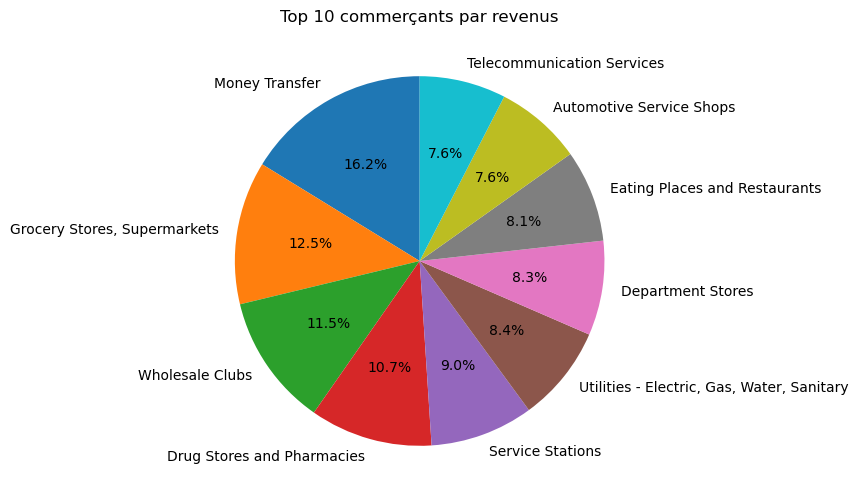

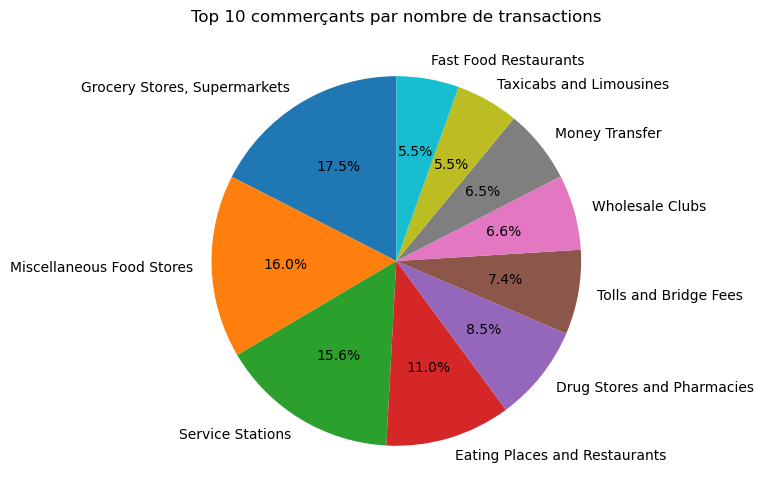

In [12]:
# Assure-toi que 'amount' est bien numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# Top 10 commerçants par revenus
top_revenue = df.groupby('description')['amount'].sum().sort_values(ascending=False).head(10)

# Top 10 commerçants par nombre de transactions
top_count = df['description'].value_counts().head(10)

# Diagramme en secteurs – revenus
plt.figure(figsize=(8, 6))
top_revenue.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par revenus')
plt.ylabel('')
plt.show()

# Diagramme en secteurs – nombre de transactions
plt.figure(figsize=(8, 6))
top_count.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par nombre de transactions')
plt.ylabel('')
plt.show()

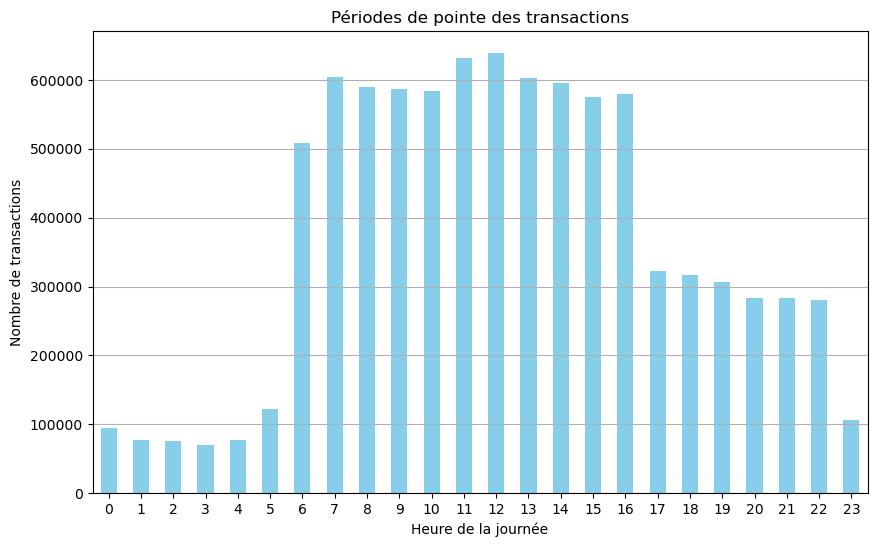

In [13]:
# Histogramme des heures
plt.figure(figsize=(10, 6))
df['heure'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Périodes de pointe des transactions')
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# **2. Analyse d'associations**

#### 2.1 *Transformation des données en données transactionnelles*


 Pour Owen, utiliser **df** pour créer les séquences, pas df1, df2 ou df3. df est la version propre de toutes les dataFrames mis ensemble. *À supprimer après lecture*

In [15]:
# Catégoriser l'heure
def categorize_hour(x):
    if x >= 22 or x < 6:
        return 'late_hour'
    else:
        return 'day_hour'
    
df['hour_category'] = df['heure'].apply(categorize_hour)

df['is_fraud_str'] = df['is_fraud'].apply(lambda x: 'Fraud' if x else 'NoFraud')

# Colonnes pour les transactions
cols_to_use =  ['card_type', 'credit_score_item', 'mcc_category', 'merchant_type', 'amount_category', 'is_fraud_str', 'hour_category']



# Gestion des valeurs manquantes
for col in cols_to_use:
    df[col] = df[col].astype(str).fillna('Unknown')

# Création des données transactionnelles (transactions)
def make_transactions(x):
    items = []
    for col in cols_to_use:
        items += x[col].tolist()
    items += x['is_fraud_str'].tolist()
    return items 

# Créer les transactions selon l'id de la carte
df_sample = df.sample(5000) 
transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()

C:\Users\lucna\AppData\Local\Temp\ipykernel_28532\3670656993.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()


In [16]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transactions_df = pd.DataFrame(te_array, columns=te.columns_)
transactions_df

,"Accounting, Auditing, and Bookkeeping Services",Airlines,"Amusement Parks, Carnivals, Circuses",Antique Shops,"Artist Supply Stores, Craft Shops","Athletic Fields, Commercial Sports",Automotive Body Repair Shops,Automotive Parts and Accessories Stores,Automotive Service Shops,Beauty and Barber Shops,...,telecommunication_services,theatrical_producers,tolls_and_bridge_fees,"tools,_parts,_supplies_manufacturing",travel_agencies,"utilities_-_electric,_gas,_water,_sanitary",very_high,welding_repair,wholesale_clubs,women's_ready-to-wear_stores
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2423,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2424,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2425,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2426,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


#### 2.2 *Génération de règles d'association par Apriori et FP-Growth*

In [17]:
# Génération des itemsets fréquents avec Apriori
frequent_itemsets_apriori = apriori(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1.2)

# Génération des itemsets fréquents avec FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.2)

# Conversion de frozenset à string pour une meilleure lisibilité
rules_apriori['antecedents'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_apriori['consequents'] = rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

rules_fpgrowth['antecedents'] = rules_fpgrowth['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_fpgrowth['consequents'] = rules_fpgrowth['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

#### 2.3, 2.4 et 2.5 *Affichage des règles transactionnelles selon les questions*

In [18]:
# Question 2.3 : MCC et dépenses élevées
import re

mcc_types = df['mcc_category'].unique()
amount_type = df['amount_category'].unique()

mcc_regex = '|'.join([re.escape(x) for x in mcc_types])
amount_regex = 'high|very_high'

rules_mcc_expenses_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(mcc_regex, case=False) &
        rules_apriori['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(amount_regex, case=False) & 
        rules_apriori['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("Règles d'association (MCC et dépenses élevées) - Apriori:")
for idx, row in rules_mcc_expenses_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_mcc_expenses_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(mcc_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(amount_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("\nRègles d'association (MCC et dépenses élevées) - FP-Growth:")
for idx, row in rules_mcc_expenses_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (MCC et dépenses élevées) - Apriori:
high -> Automotive Service Shops (support: 0.040, lift: 1.67)
Automotive Service Shops -> high (support: 0.040, lift: 1.67)
Department Stores -> high (support: 0.033, lift: 1.27)
high -> Department Stores (support: 0.033, lift: 1.27)
very_high -> Department Stores (support: 0.036, lift: 1.50)

Règles d'association (MCC et dépenses élevées) - FP-Growth:
miscellaneous_food_stores, Service Stations -> very_high (support: 0.026, lift: 1.80)
miscellaneous_food_stores, very_high -> Service Stations (support: 0.026, lift: 1.54)
Service Stations -> miscellaneous_food_stores, very_high (support: 0.026, lift: 1.54)
very_high -> miscellaneous_food_stores, Service Stations (support: 0.026, lift: 1.80)
miscellaneous_food_stores, Service Stations -> high (support: 0.024, lift: 1.60)


Par la sortie qui suit, on voit que dans notre DataFrame prétraité, il y a des associations entre le type de commerce et les hautes dépenses. Les quatres commerces les plus concernés sont *Automotive Service Shops*, *Departement Stores*, *Miscellaneous Food Stores* et *Services Stations*, où les dépenses varient de hautes à très hautes. Les patterns comportementaux qui ressortent sont que les gens dépensent de grandes sommes dans les magasins départementales, dans les magasins de réparation automobile, dans les magasins de nourriture divers et dans les stations de services.

In [19]:
# Question 2.4 : Types de cartes et types de commerçants
import re

card_types = df['card_type'].unique()
merchant_types = df['merchant_type'].unique()

# Créer une regex qui matche n'importe quelle valeur
card_regex = '|'.join([re.escape(str(x)) for x in card_types])
merchant_regex = '|'.join([re.escape(str(x)) for x in merchant_types])

rules_card_merchant_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(card_regex, case=False) & 
        rules_apriori['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_apriori['consequents'].str.contains(card_regex, case=False)
    )
]

print("Règles d'association (Types de cartes et types de commerçants) - Apriori:")
for idx, row in rules_card_merchant_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_card_merchant_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(card_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(card_regex, case=False)
    )   
]

print("\nRègles d'association (Types de cartes et types de commerçants) - FP-Growth:")
for idx, row in rules_card_merchant_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (Types de cartes et types de commerçants) - Apriori:
Credit -> department_stores (support: 0.027, lift: 1.25)
department_stores -> Credit (support: 0.027, lift: 1.25)
Credit -> money_transfer (support: 0.030, lift: 1.22)
money_transfer -> Credit (support: 0.030, lift: 1.22)
book_stores -> Debit (support: 0.026, lift: 1.25)

Règles d'association (Types de cartes et types de commerçants) - FP-Growth:
credit_high, low -> miscellaneous_food_stores (support: 0.070, lift: 1.67)
miscellaneous_food_stores -> credit_high, low (support: 0.070, lift: 1.67)
credit_high, low, Debit -> miscellaneous_food_stores (support: 0.044, lift: 1.63)
miscellaneous_food_stores, Debit -> credit_high, low (support: 0.044, lift: 1.64)
miscellaneous_food_stores, credit_high -> low, Debit (support: 0.044, lift: 1.67)


Ici, les deux seules associations pertinentes sont entre les commerçants transferant de l'argent et le type de carte *Credit* et entre les libraires et le type de carte *Debit*. Cela nous révèle que les utilisateurs utilisent surtout des cartes de crédit lorsqu'ils veulent transférer de l'argent et des cartes de débit pour acheter des livres.

In [20]:
# Question 2.5 : Fraude et autres variables
rules_fraud_ap = rules_apriori[
    ( 
        rules_apriori['consequents'].str.contains('Fraud', case=False)
    )
]

print("Règles d'association (Fraude et autres variables) - Apriori:")
for idx, row in rules_fraud_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_fraud_fp = rules_fpgrowth[
    ( 
        rules_fpgrowth['consequents'].str.contains('Fraud', case=False)
    )
]

print("\nRègles d'association (Fraude et autres variables) - FP-Growth:")
for idx, row in rules_fraud_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (Fraude et autres variables) - Apriori:
automotive_service_shops -> NoFraud, Automotive Service Shops (support: 0.061, lift: 16.52)
Automotive Service Shops -> automotive_service_shops, NoFraud (support: 0.061, lift: 16.52)
high -> NoFraud, Automotive Service Shops (support: 0.040, lift: 1.67)
Automotive Service Shops -> high, NoFraud (support: 0.040, lift: 1.67)
Book Stores -> NoFraud, Debit (support: 0.026, lift: 1.25)

Règles d'association (Fraude et autres variables) - FP-Growth:
very_high, high, medium -> NoFraud, Debit, day_hour (support: 0.029, lift: 1.21)
Debit, day_hour -> very_high, NoFraud, high, medium (support: 0.029, lift: 1.21)
very_high, low, medium -> NoFraud, Debit, day_hour (support: 0.025, lift: 1.21)
Debit, day_hour -> very_high, NoFraud, low, medium (support: 0.025, lift: 1.21)
very_high -> Credit, NoFraud (support: 0.149, lift: 1.22)


On peut voir qu'on ne trouve aucune corrélation entre les autres variables et la fraude, surtout parce que toutes les règles ne pointent pas vers de la fraude. On peut voir cela par le fait que le lift est supérieur au minimum posé, soit 1.2, signifiant une corrélation positive, surtout les deux premières règles crées par *Apriori*. 

#### 2.6 *Explication et visualisation des métriques associés aux règles*

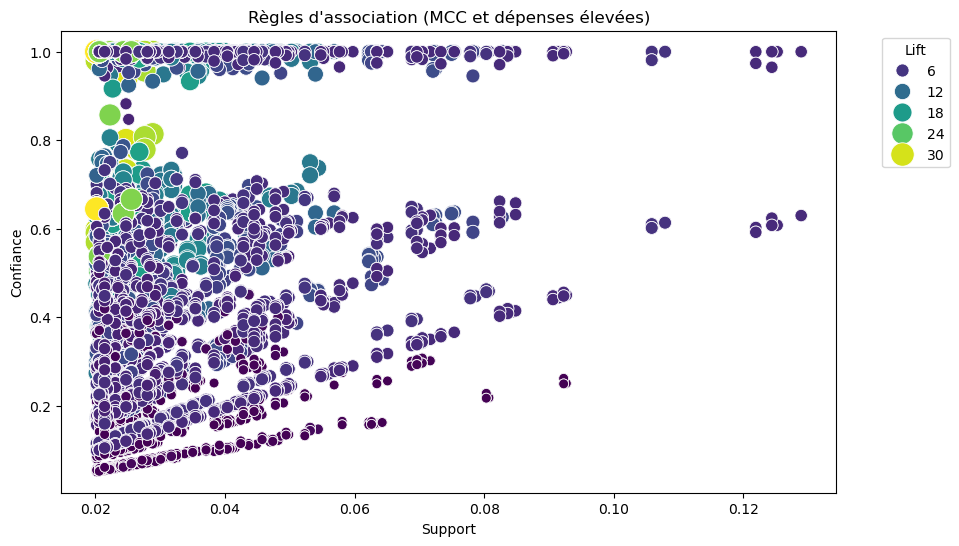

In [21]:
rules_mcc_expenses_copy = rules_mcc_expenses_ap.copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    data=rules_mcc_expenses_copy,
    palette='viridis',
    sizes=(50, 300)
)

plt.title('Règles d\'association (MCC et dépenses élevées)')
plt.xlabel('Support')
plt.ylabel('Confiance')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

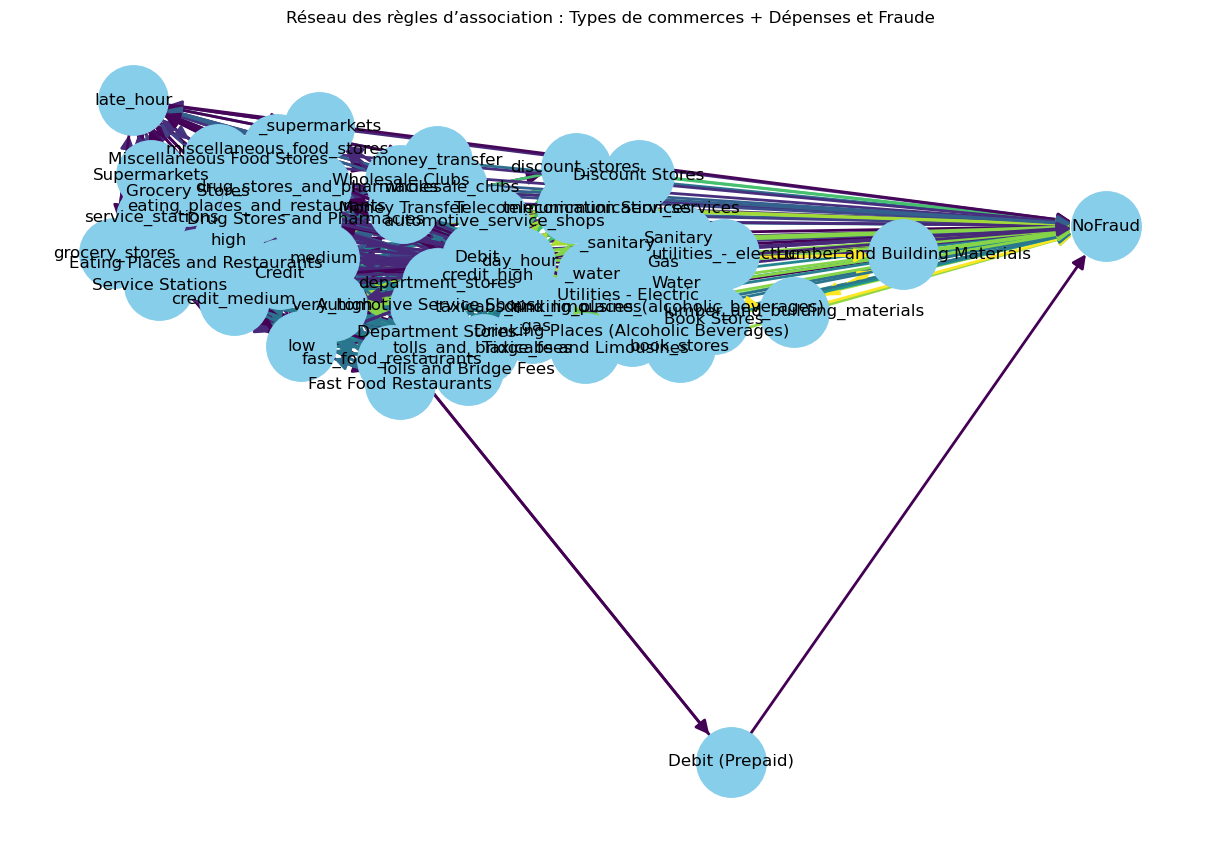

In [22]:
import networkx

rules_fraud_ap_copy = rules_fraud_ap.copy()

# Graphe orienté
G = networkx.DiGraph()

# Ajouter les arêtes avec les poids basés sur le lift
for idx, row in rules_fraud_ap_copy.iterrows():
    antecedents = [x.strip() for x in row['antecedents'].split(',')]
    consequents = [x.strip() for x in row['consequents'].split(',')]
    for a in antecedents:
        for c in consequents:
            G.add_edge(a, c, weight=row['lift'])

# Taille des arêtes basée sur le lift
edges = G.edges()
weights = [G[u][v]['weight']*2 for u,v in edges]

# Dessiner le graphe
plt.figure(figsize=(12, 8))
pos = networkx.spring_layout(G, k=0.5, seed=42)
networkx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2500, 
        edge_color=weights, width=2, edge_cmap=plt.cm.viridis, arrowsize=20)
plt.title('Réseau des règles d’association : Types de commerces + Dépenses et Fraude')
plt.show()


Le support correspond au pourcentage de *"popularité"* dans le sens que sur 2428 transactions, le pourcentage montré est le nombre de transactions où la règle apparaît le plus souvent. La confiance correspond au pourcentage de *"fiabilité*, soit que par rapport au support, un pourcentage de transactions suit une règle contenant plusieurs arguments à gauche comme un haut crédit, des dépenses basses et la librairie. Le lift correspond à la pertinence de la règle et si la limite posée est dépassée, cela signifie que ce n'est pas par hasard que les arguments de la règle sont associés entre eux (corrélation positive). Si on a un lift égal à la limite, les arguments de la règle sont indépendants (aucune corrélation). Si on a un lift inférieur à la limite, les arguments de la règle n'ont aucun lien entre eux (corrélation négative).

#### 2.7 *Choix du seuil du support minimal*

Pour le seuil de support minimal, on a choisi d'aller avec 0.02, afin de prendre en compte, à la fois les cas spécifiques et les cas généraux, sans avoir trop de bruit dans les données et sans manquer de cas spécifiques. Puisque qu'on est à un peu moins de 5000 transactions, cette valeur est très justifié. 

(On a pris un échantillon de 5000 pour des fins de tests. Lancer des millions de transactions dans des algorithmes comme *Apriori* et *FP-Growth* ne ferait que ralentir le processus en plus de causer énormément de bruit dans les résultats)